## 4.4 하이브리드 양자 오류 정정 기법 — 저밀도 패리티 검사(LDPC) 부호

In [1]:
from qiskit import QuantumCircuit, transpile  # 호환성 수정(qiskit 2.x): assemble 제거됨
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import  Statevector
import matplotlib.pyplot as plt

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 양자 오류 정정 부호 시뮬레이션 - 개념 구현

# 1단계: 단순화한 LDPC형 부호의 양자 회로 정의
n_qubits = 5
qc = QuantumCircuit(n_qubits, n_qubits)

In [3]:
# 2단계: 간단한 오류 정정 부호를 만들기 위한 게이트 적용

# 예: 인코딩된 상태 준비
qc.h(0)  # 큐비트 0에 하다마드 게이트
qc.cx(0, 1)  # 큐비트 0과 1을 얽음 (패리티 검사)
qc.cx(0, 2)  # 큐비트 0과 2를 얽음 (또 다른 패리티 검사)
qc.cx(1, 3)  # 큐비트 1과 3을 얽음
qc.cx(2, 4)  # 큐비트 2와 4를 얽음

In [4]:
# 3단계: X 게이트로 오류(비트 반전) 흉내
qc.x(1)  # 큐비트 1에 X 게이트로 오류 시뮬레이션

In [5]:
# 4단계: 패리티 검사(신드롬 측정) 적용
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(1, 3)
qc.cx(2, 4)

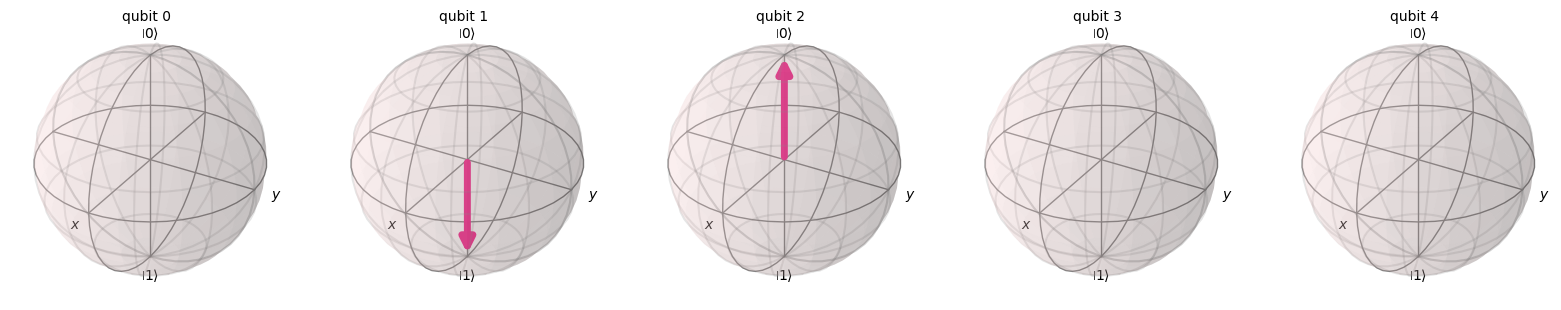

In [6]:
# 측정 전 상태벡터를 얻어 블로흐 구로 그리기
statevector = Statevector.from_instruction(qc)
plot_bloch_multivector(statevector)
plt.show()

In [7]:
# 5단계: 모든 큐비트 측정
qc.measure(range(n_qubits), range(n_qubits))

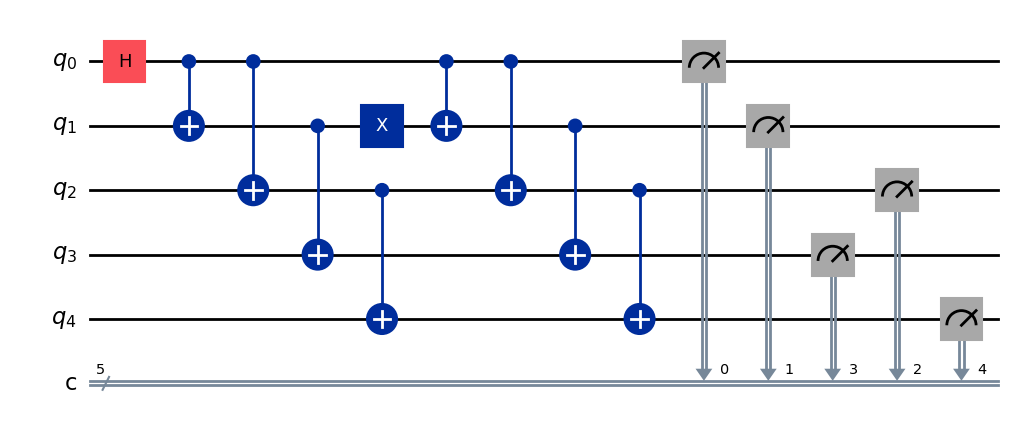

In [8]:
# 회로 그리기
qc.draw('mpl')
plt.show()

In [9]:
# 6단계: Qiskit AerSimulator로 회로 트랜스파일·시뮬레이션
simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)
qobj = compiled_qc  # 호환성 수정(qiskit 2.x): assemble 제거 → 트랜스파일된 회로를 그대로 사용
result = simulator.run(qobj).result()

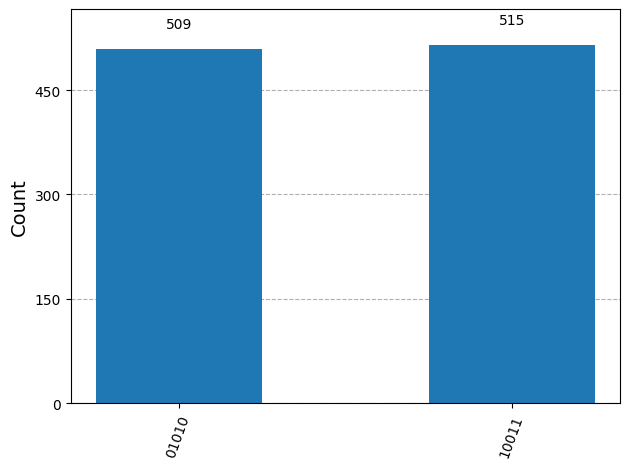

In [10]:
# 7단계: 측정 결과 추출 및 그리기
counts = result.get_counts(compiled_qc)
plot_histogram(counts)
plt.show()